In [147]:
import numpy as np
import pandas as pd
import joblib
import tensorflow as tf

from tensorflow import keras

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score
)

In [148]:
model = keras.models.load_model(
    "../models/fraud_detection_ann.keras"
)

In [149]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,829 (54.02 KB)

 Trainable params: 4,609 (18.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 9,220 (36.02 KB)

In [150]:
scaler = joblib.load(
    "../models/scaler.pkl"
)

In [151]:
import pandas as pd

df = pd.read_csv("../data/raw/creditcard.csv")

print(df.shape)

(284807, 31)


In [152]:
df = df.drop_duplicates()

print(df.shape)

(283726, 31)


In [153]:
X = df.drop("Class", axis=1)
y = df["Class"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (283726, 30)
y shape: (283726,)


In [154]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [155]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

In [156]:
print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (181584, 30)
Testing: (56746, 30)


In [157]:
X_val_scaled = scaler.transform(X_val)

X_test_scaled = scaler.transform(X_test)

In [158]:
y_pred_prob = model.predict(X_test_scaled)

1774/1774 ━━━━━━━━━━━━━━━━━━━━ 0s 219us/step


In [159]:
y_val_prob = model.predict(X_val_scaled).ravel()

1419/1419 ━━━━━━━━━━━━━━━━━━━━ 0s 209us/step


In [160]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.1, 1.0, 0.1)

results = []

for threshold in thresholds:

    y_val_pred = (y_val_prob >= threshold).astype(int)

    precision = precision_score(
        y_val,
        y_val_pred,
        zero_division=0
    )

    recall = recall_score(
        y_val,
        y_val_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_val,
        y_val_pred,
        zero_division=0
    )

    results.append([
        threshold,
        precision,
        recall,
        f1
    ])

In [161]:
threshold_results = pd.DataFrame(
    results,
    columns=[
        "Threshold",
        "Precision",
        "Recall",
        "F1"
    ]
)

print(threshold_results)

   Threshold  Precision    Recall        F1
0        0.1   0.024699  1.000000  0.048208
1        0.2   0.037707  0.986842  0.072639
2        0.3   0.052484  0.986842  0.099668
3        0.4   0.066787  0.973684  0.125000
4        0.5   0.083620  0.960526  0.153846
5        0.6   0.103198  0.934211  0.185864
6        0.7   0.141414  0.921053  0.245184
7        0.8   0.212308  0.907895  0.344140
8        0.9   0.361702  0.894737  0.515152


In [162]:
best_row = threshold_results.loc[
    threshold_results["F1"].idxmax()
]

print(best_row)

Threshold    0.900000
Precision    0.361702
Recall       0.894737
F1           0.515152
Name: 8, dtype: float64


In [163]:
thresholds_fine = np.arange(0.50, 1.00, 0.01)

fine_results = []

for threshold in thresholds_fine:

    y_val_pred = (y_val_prob >= threshold).astype(int)

    precision = precision_score(
        y_val,
        y_val_pred,
        zero_division=0
    )

    recall = recall_score(
        y_val,
        y_val_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_val,
        y_val_pred,
        zero_division=0
    )

    fine_results.append([
        threshold,
        precision,
        recall,
        f1
    ])

fine_results = pd.DataFrame(
    fine_results,
    columns=[
        "Threshold",
        "Precision",
        "Recall",
        "F1"
    ]
)

In [164]:
best_threshold_row = fine_results.loc[
    fine_results["F1"].idxmax()
]

print(best_threshold_row)

Threshold    0.990000
Precision    0.767442
Recall       0.868421
F1           0.814815
Name: 49, dtype: float64


In [165]:
print(y_pred_prob[:10])


[[4.4055490e-04]
 [5.1139076e-03]
 [3.2083474e-03]
 [2.4903691e-03]
 [2.9798998e-02]
 [1.3569857e-02]
 [7.0393545e-04]
 [2.3393780e-03]
 [2.4464173e-02]
 [6.5143853e-05]]


In [166]:
y_pred = (y_pred_prob >= 0.5).astype(int)

In [167]:
print(y_pred[:10])

[[0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]]


In [168]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[55605  1046]
 [   13    82]]


In [169]:
print("True Negatives :", cm[0, 0])
print("False Positives:", cm[0, 1])
print("False Negatives:", cm[1, 0])
print("True Positives  :", cm[1, 1])

True Negatives : 55605
False Positives: 1046
False Negatives: 13
True Positives  : 82


In [170]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56651
           1       0.07      0.86      0.13        95

    accuracy                           0.98     56746
   macro avg       0.54      0.92      0.56     56746
weighted avg       1.00      0.98      0.99     56746



In [171]:
from sklearn.metrics import roc_auc_score, average_precision_score

roc_auc = roc_auc_score(y_test, y_pred_prob)
pr_auc = average_precision_score(y_test, y_pred_prob)

print("ROC-AUC:", roc_auc)
print("PR-AUC:", pr_auc)

ROC-AUC: 0.9590281771399958
PR-AUC: 0.6870140247598963


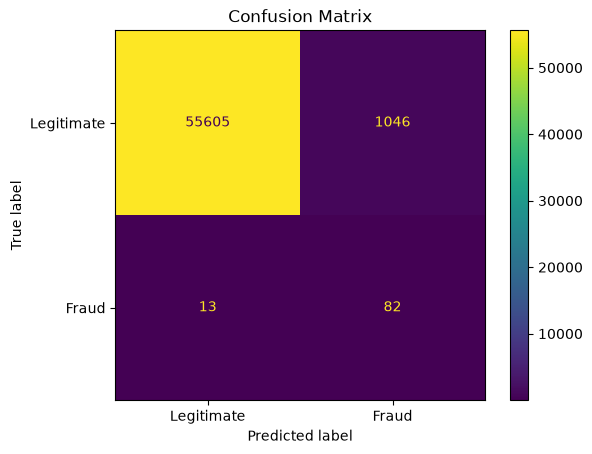

In [172]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Legitimate", "Fraud"]
).plot()

plt.title("Confusion Matrix")
plt.show()

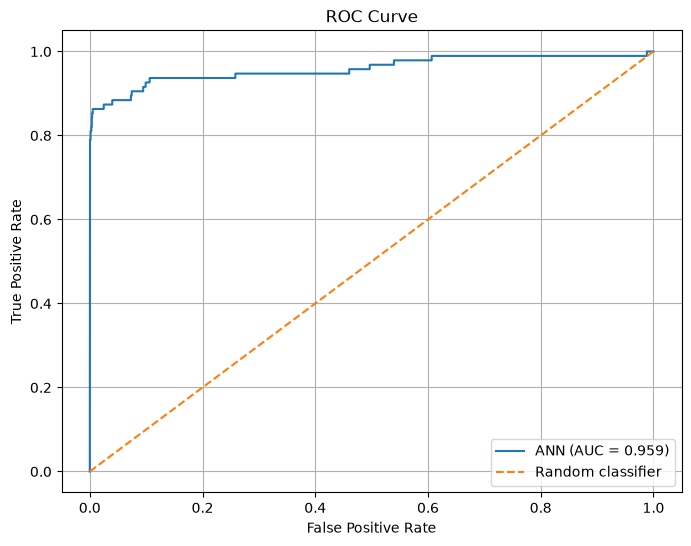

In [173]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_pred_prob
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"ANN (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()

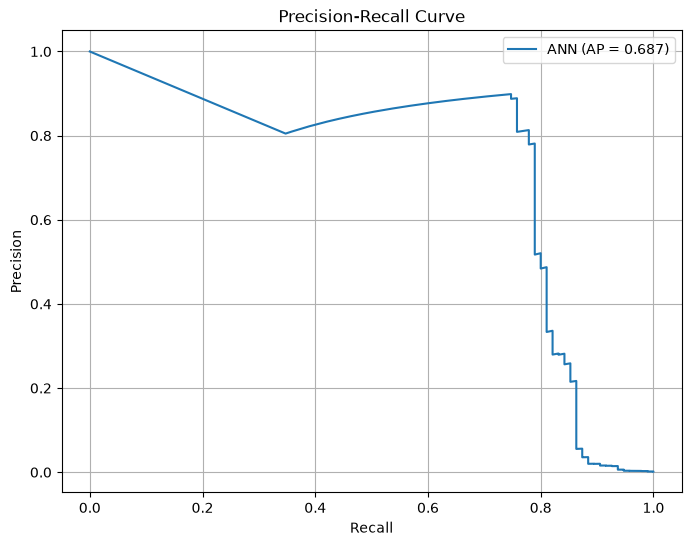

In [174]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds_pr = precision_recall_curve(
    y_test,
    y_pred_prob
)

plt.figure(figsize=(8, 6))

plt.plot(
    recall,
    precision,
    label=f"ANN (AP = {pr_auc:.3f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid()
plt.show()

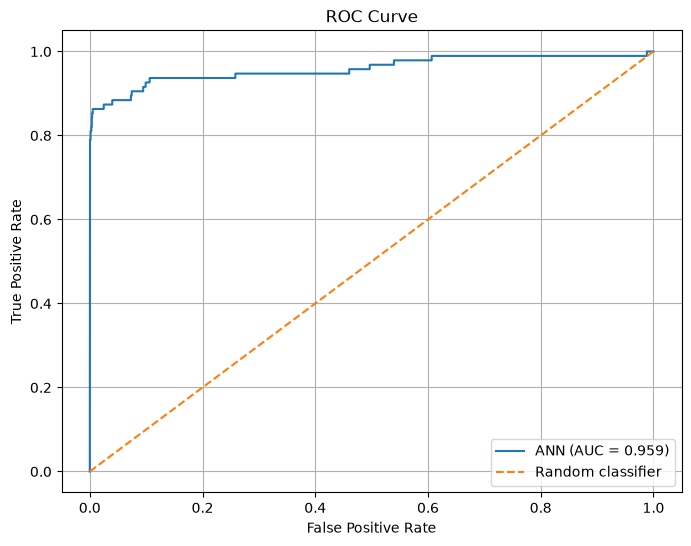

In [175]:
plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"ANN (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()

plt.savefig(
    "../images/roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

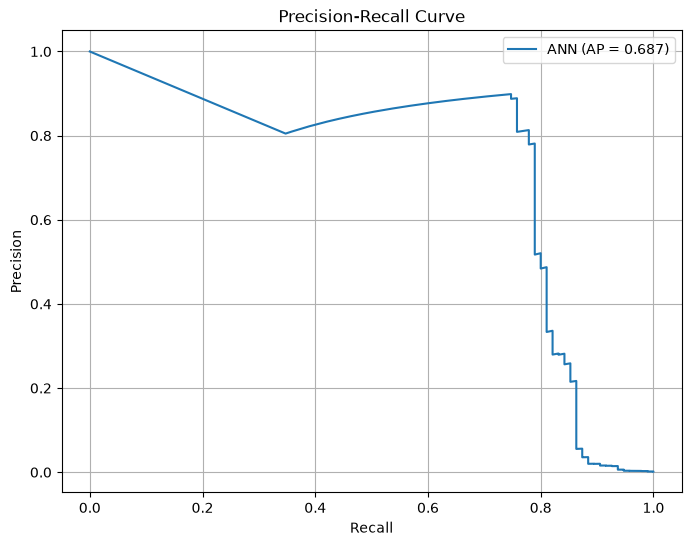

In [176]:
plt.figure(figsize=(8, 6))

plt.plot(
    recall,
    precision,
    label=f"ANN (AP = {pr_auc:.3f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid()

plt.savefig(
    "../images/precision_recall_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [178]:
y_test_prob = model.predict(X_test_scaled).ravel()

1774/1774 ━━━━━━━━━━━━━━━━━━━━ 0s 214us/step


In [179]:
best_threshold = 0.99

y_test_pred = (
    y_test_prob >= best_threshold
).astype(int)

In [180]:
cm_final = confusion_matrix(
    y_test,
    y_test_pred
)

print(cm_final)

[[56632    19]
 [   21    74]]


In [181]:
print("True Negatives :", cm_final[0, 0])
print("False Positives:", cm_final[0, 1])
print("False Negatives:", cm_final[1, 0])
print("True Positives  :", cm_final[1, 1])

True Negatives : 56632
False Positives: 19
False Negatives: 21
True Positives  : 74


In [182]:
final_roc_auc = roc_auc_score(
    y_test,
    y_test_prob
)

final_pr_auc = average_precision_score(
    y_test,
    y_test_prob
)

print("ROC-AUC:", final_roc_auc)
print("PR-AUC:", final_pr_auc)

ROC-AUC: 0.9590281771399958
PR-AUC: 0.6870140247598963


In [183]:
print(
    classification_report(
        y_test,
        y_test_pred,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.80      0.78      0.79        95

    accuracy                           1.00     56746
   macro avg       0.90      0.89      0.89     56746
weighted avg       1.00      1.00      1.00     56746



In [185]:
final_roc_auc = roc_auc_score(
    y_test,
    y_test_prob
)

final_pr_auc = average_precision_score(
    y_test,
    y_test_prob
)

print("ROC-AUC:", final_roc_auc)
print("PR-AUC:", final_pr_auc)

ROC-AUC: 0.9590281771399958
PR-AUC: 0.6870140247598963


In [186]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

final_metrics = {
    "Threshold": best_threshold,
    "Precision": precision_score(y_test, y_test_pred),
    "Recall": recall_score(y_test, y_test_pred),
    "F1-Score": f1_score(y_test, y_test_pred),
    "ROC-AUC": roc_auc_score(y_test, y_test_prob),
    "PR-AUC": average_precision_score(y_test, y_test_prob)
}

print(final_metrics)

{'Threshold': 0.99, 'Precision': 0.7956989247311828, 'Recall': 0.7789473684210526, 'F1-Score': 0.7872340425531915, 'ROC-AUC': 0.9590281771399958, 'PR-AUC': 0.6870140247598963}


In [187]:
metrics_df = pd.DataFrame(
    [final_metrics]
)

metrics_df.to_csv(
    "../results/evaluation_metrics.csv",
    index=False
)